In [1]:
import csv
import numpy as np


from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import KFold

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

## Loading data from a .csv file

In [2]:
## Define the filename
filename='data\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

## Initialize lists for storing data, labels and header
data=[]
label=[]
header=[]

## Open the file stream
csv_file=open(filename)
csv_reader=csv.reader(csv_file)

## Extract the header so that it does not go into the data
header = next(csv_reader)

## Read the file line by line
## To keep dimension reasonable, only one line every 10 is read
## Append the read data into the data list
## Append the label (last element of the row) to the label list
j=0
for row in csv_reader:
    j=j+1
    if (j%10) == 0:
        data.append(row[0:-2])

        if row[-1]=='BENIGN':
            label.append(0)
        else:
            label.append(1)

In [3]:
## Convert list in numerical numpy matrices of floating point 

data_mat=np.array(data).astype(np.float64)
label_mat=np.array(label)

print(data_mat.shape)

(22573, 77)


## Train a Ada-Boost classifier and evaluate its performance

In [4]:

clf = AdaBoostClassifier(n_estimators=10, random_state=0)
clf.fit(data_mat, label_mat)
label_hat=clf.predict(data_mat)

Pr = precision_score(label_mat,label_hat)

Rc = recall_score(label_mat,label_hat)

F1 = f1_score(label_mat,label_hat)

print(Pr)
print(Rc)
print(F1)

0.9992967101664453
0.9989064208717388
0.9991015274034142


## Train a KNN classifier and evaluate its performance

In [5]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(data_mat, label_mat)
label_hat=clf.predict(data_mat)

Pr = precision_score(label_mat,label_hat)

Rc = recall_score(label_mat,label_hat)

F1 = f1_score(label_mat,label_hat)

print(Pr)
print(Rc)
print(F1)

0.9911552486616495
0.9978909545383534
0.9945116967031257


In [6]:
Pr=np.array([])
Rc=np.array([])
F1=np.array([])
Acc=np.array([])

for n in range(20):
    clf = KNeighborsClassifier(n_neighbors=n+1)
    clf.fit(data_mat, label_mat)
    label_hat=clf.predict(data_mat)

    Pr = np.append(Pr,precision_score(label_mat,label_hat))
    Rc = np.append(Rc,recall_score(label_mat,label_hat))
    F1 = np.append(F1,f1_score(label_mat,label_hat))
    Acc = np.append(Acc,accuracy_score(label_mat,label_hat))
    

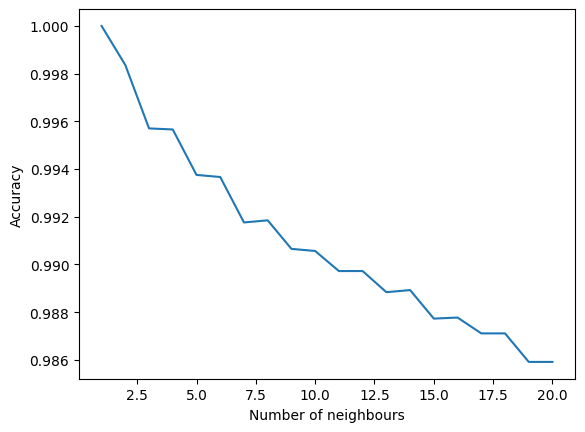

In [7]:
plt.plot(np.arange(20)+1,Acc)
plt.xlabel('Number of neighbours')
plt.ylabel('Accuracy')

plt.show()